1. Web Scraping [20 puntos]:
- U@lizar técnicas de Web Scraping para extraer información de al menos 500 bebidas alcohólicas del
si@o web hGps://dis@ller.com/search.
- Los datos a obtener para cada bebida están definidos por las siguientes columnas que se pueden
extraer de la página asociada a la bebida:
columns=['Name', 'Type', 'Cask', 'Location', 'Age', 'ABV %', 'Cost',
'Badge', '# Ratings', "Community Rating", 'Flavor Summary', 'Expert',
'Expert Score', 'Smoky', 'Earthy', 'Spicy', 'Herbal', 'Oily', 'Bitter',
'Rich', 'Sweet', 'Mineral', 'Salty', 'Umami', 'Tart', 'Fruity',
'Floral', 'Review'])
- Almacenar los datos obtenidos en un DataFrame de Pandas. Los datos deberían verse como en la
Figura 2 (aproximadamente).
Figura 2. Ejemplo de la planilla de datos obtenida con Web Scraping.

In [1]:
from selenium import webdriver
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC 
from selenium.webdriver.common.by import By
from selenium.webdriver import Chrome
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

In [2]:
df = pd.DataFrame(columns=['name', 'type', 'cask', 'location', 'age', 'abv %', 'cost', 
'badge', '# ratings', "community rating", 'flavor summary', 'expert', 
'expert score', 'smoky', 'earthy', 'spicy', 'herbal', 'oily', 'bitter', 
'rich', 'sweet', 'mineral', 'salty', 'umami', 'tart', 'fruity', 
'floral'])

In [3]:
def startDriver() -> webdriver.Chrome:
	service = Service(ChromeDriverManager().install())
	options = Options()
	options.add_argument("--disable-extensions")
	options.add_argument("--headless")
	driver = Chrome(service=service, options=options)
	return driver
driver = startDriver()

In [4]:
def extractLinks():
    WebDriverWait(driver, 20).until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button.align-right.secondary.slidedown-button"))).click()
    WebDriverWait(driver, 20).until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button.banner__close.privacy__banner"))).click()

    WebDriverWait(driver, 5).until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button.spirit-family-select__button.js-select-spirit-family.all.selected"))).click()
    WebDriverWait(driver, 5).until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'button[data-value="agave"]'))).click()

    hrefs = []

    for x in range(1, 51):
        driver.get(f"{url}{x}")
        elements = driver.find_elements(By.CSS_SELECTOR, "li.spirit.agave-content")
        for element in elements:
            hrefs.append(element.find_element(By.TAG_NAME, "a").get_attribute("href"))

    for href in hrefs:
        print(href)
    return hrefs

In [5]:
def extractProductDetails(hrefs):
    for href in hrefs:
        driver.get(href)
        
        #Nombre
        try:
            name = driver.find_element(By.XPATH, "/html/body/div[7]/div/div/main/div/div[1]/div[1]/div[3]/h1").text
            if name == "":
                name = "unknown"
        except:
            name = "unknown"
        #Tipo

        try:   
            types = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[1]/div[3]/div/p[1]").text
            if types == "":
                types = pd.NA
        except:
            types = pd.NA
        #Cask
        try:
            cask = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[2]/div[3]/ul/li[3]/div[2]").text
            if cask == "":
                cask = "unknown"    
        except:
            cask = "unknown"
        #Location y badge

        try:
            temp = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[1]/div[3]/div/p[2]").text.split("// ")

            location = temp[1]
            badge = temp[0]

            if location == "":
                location = "unknown"
            if badge == "":
                badge = "unknown"
        except:
            location = "unknown"
            badge = "unknown"

        #age

        try:
            age = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[2]/div[3]/ul/li[1]/ul/li[1]/div[2]").text
            if age == "":
                age = "unknown"
        except:
            age = "unknown"

        #ABV
        try:
            abv = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[2]/div[3]/ul/li[1]/ul/li[3]/div[2]").text
            if abv == "":
                abv = pd.NA 
        except:
            abv = pd.NA

        #Cost
        try:
            cost = driver.find_element(By.XPATH, "/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[2]/div[3]/ul/li[1]/ul/li[2]/div[2]/div").get_attribute("class")[-1]
            if cost == "":  
                cost = pd.NA
        except:
            cost = pd.NA

        #Ratings
        try:
            ratings = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[1]/div/div/div/div/div[3]/a/span[2]").text
            if ratings == "":
                ratings = "unknown"
        except:
            ratings = "unknown"

        #Community Rating
        try:
            community_rating = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[1]/div/div/div/div/div[1]/span").text
            if community_rating == "" or community_rating == "No one has reviewed this yet. Be the first":
                community_rating = "unknown"
        except:
            community_rating = "unknown"

        #Flavor Summary
        try:
            flavor_summary = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[5]/h3").text
            if flavor_summary == "":
                flavor_summary = "unknown"
        except:
            flavor_summary = "unknown"  

        #Expert
        try:
            expert = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[3]/div[2]/div[1]/a").text
            if expert == "":
                expert = "unknown"
        except:
            expert = "unknown"

        #Expert Score
        try:
            expert_score = driver.find_element(By.XPATH,"/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[3]/div[2]/div[2]/span").text
            if expert_score == "":
                expert_score = "unknown"
        except:
            expert_score = "unknown"
        

        #Flavor Profile
        canvas_element = driver.find_element(By.XPATH, "/html/body/div[7]/div/div/main/div/div[1]/div[2]/div[1]/div/div/div[5]/canvas")
        data_flavors = canvas_element.get_attribute("data-flavors")
        
        df_2 = pd.DataFrame([json.loads(data_flavors)])

        #Create df_1
        df_1 = {
            'name': name,
            'type': types,
            'cask': cask,
            'location': location,
            'age': age,
            'abv %': abv,
            'cost': cost,
            'badge': badge,
            '# ratings': ratings,
            'community rating': community_rating,
            'flavor summary': flavor_summary,
            'expert': expert,
            'expert score': expert_score
        }

        df_1 = pd.DataFrame([df_1])
        

        #Concatenate df_1 and df_2
        df_1 = pd.concat([df_1, df_2], axis=1)

        #Append to df
        df = pd.concat([df, df_1], ignore_index=True)

# IMPORTANTE:
> Si deseas generar el archivo distiler.csv (actualizar o crear en caso de que no lo tengas a mano), simplemente debes borrar los **"""** del codigo de abajo, debido a que para temas practicos de prueba, se decidio no utilizar esa seccion al momento de continuar con el taller. 

In [6]:
""" BORRABLE
hrefs = extractLinks()
url = "https://distiller.com/search?page="
driver.get(url)
driver.quit()

driver = startDriver()
extractProductDetails(hrefs)
driver.quit()
df = df.dropna()
df.to_csv("distiler.csv", index=False)
""" 

' BORRABLE\nhrefs = extractLinks()\nurl = "https://distiller.com/search?page="\ndriver.get(url)\ndriver.quit()\n\ndriver = startDriver()\nextractProductDetails(hrefs)\ndriver.quit()\ndf = df.dropna()\ndf.to_csv("distiler.csv", index=False)\n'

### 2. Preprocesamiento de datos [20 puntos]:
---
1. Realizar una exploración inicial de los datos obtenidos mediante estadís@cas básicas y visualización
de cada variable relevante, identificando posibles valores faltantes, outliers o inconsistencias.
2. Aplicar técnicas de preprocesamiento según sea necesario.
3. Dividir los datos en conjuntos de entrenamiento y prueba, con una proporción 80/20 o 70/30 según
sea necesario/convenient.

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              500 non-null    object 
 1   type              500 non-null    object 
 2   cask              499 non-null    object 
 3   location          500 non-null    object 
 4   age               500 non-null    object 
 5   abv %             497 non-null    float64
 6   cost              500 non-null    int64  
 7   badge             500 non-null    object 
 8   # ratings         500 non-null    object 
 9   community rating  500 non-null    object 
 10  flavor summary    500 non-null    object 
 11  expert            500 non-null    object 
 12  expert score      500 non-null    int64  
 13  smoky             500 non-null    int64  
 14  earthy            500 non-null    int64  
 15  spicy             500 non-null    int64  
 16  herbal   

,name,type,cask,location,age,abv %,cost,badge,# ratings,community rating,...,oily,bitter,rich,sweet,mineral,salty,umami,tart,fruity,floral
0,4 COPAS TEQUILA BLANCO,TEQUILA BLANCO,UNAGED,"JALISCO, MEXICO",UNAGED,40.0,2,4 COPAS,44,4.37,...,10,0,70,25,20,10,25,20,65,50
1,MEZCAL LOS SIETE MISTERIOS PECHUGA,MEZCAL JOVEN,NONE,"OAXACA, MEXICO",NAS,58.5,5,LOS SIETE MISTERIOS,37,4.41,...,25,15,70,75,60,20,10,40,80,70
2,DEL MAGUEY ARROQUEÑO MEZCAL,MEZCAL JOVEN,unknown,"OAXACA, MEXICO",unknown,49.0,4,DEL MAGUEY,71,4.5,...,65,30,70,80,80,50,40,90,85,60
3,FUENTESECA RESERVA EXTRA AÑEJO TEQUILA 9 AÑOS,TEQUILA EXTRA AÑEJO,AMERICAN OAK EX-RED WINE BARRELS (85%) AND USE...,"LOS ALTOS, JALISCO, MEXICO",9 YEAR,43.0,5,FUENTESECA,8,4.11,...,65,15,80,55,30,55,55,20,90,30
4,MIJENTA TEQUILA AÑEJO GRAN RESERVA,TEQUILA AÑEJO,"AMERICAN WHITE OAK, FRENCH OAK, FRENCH ACACIA ...","LOS ALTOS, JALISCO, MEXICO",NAS,40.0,5,MIJENTA,7,4.25,...,15,35,50,30,0,0,0,45,30,0



Estadísticas descriptivas:


,abv %,cost,expert score,smoky,earthy,spicy,herbal,oily,bitter,rich,sweet,mineral,salty,umami,tart,fruity,floral
count,497.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,42.423843,2.982000,89.882000,25.700000,35.548000,40.808000,44.742000,24.056000,19.24400,53.638000,49.796000,27.980000,20.560000,21.314000,22.086000,45.844000,20.716000
std,3.733839,1.007823,3.399882,24.388596,23.885576,21.507773,23.978853,20.317541,20.01083,20.574683,21.232051,23.388665,22.827365,24.622753,20.183988,22.830728,23.744704
min,35.000000,1.000000,84.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,2.000000,87.000000,5.000000,15.000000,25.000000,25.000000,10.000000,5.00000,40.000000,30.000000,10.000000,0.000000,0.000000,5.000000,30.000000,0.000000
50%,40.000000,3.000000,90.000000,20.000000,30.000000,35.000000,40.000000,20.000000,10.00000,55.000000,50.000000,20.000000,10.000000,10.000000,15.000000,40.000000,10.000000
75%,45.000000,4.000000,92.000000,40.000000,55.000000,60.000000,65.000000,30.000000,30.00000,70.000000,67.000000,45.000000,30.000000,30.000000,35.000000,65.000000,30.000000
max,58.500000,5.000000,98.000000,95.000000,99.000000,95.000000,90.000000,86.000000,85.00000,96.000000,95.000000,87.000000,89.000000,90.000000,90.000000,99.000000,90.000000



Valores faltantes por columna:
cask     1
abv %    3
dtype: int64

Visualizando distribuciones de variables numéricas:


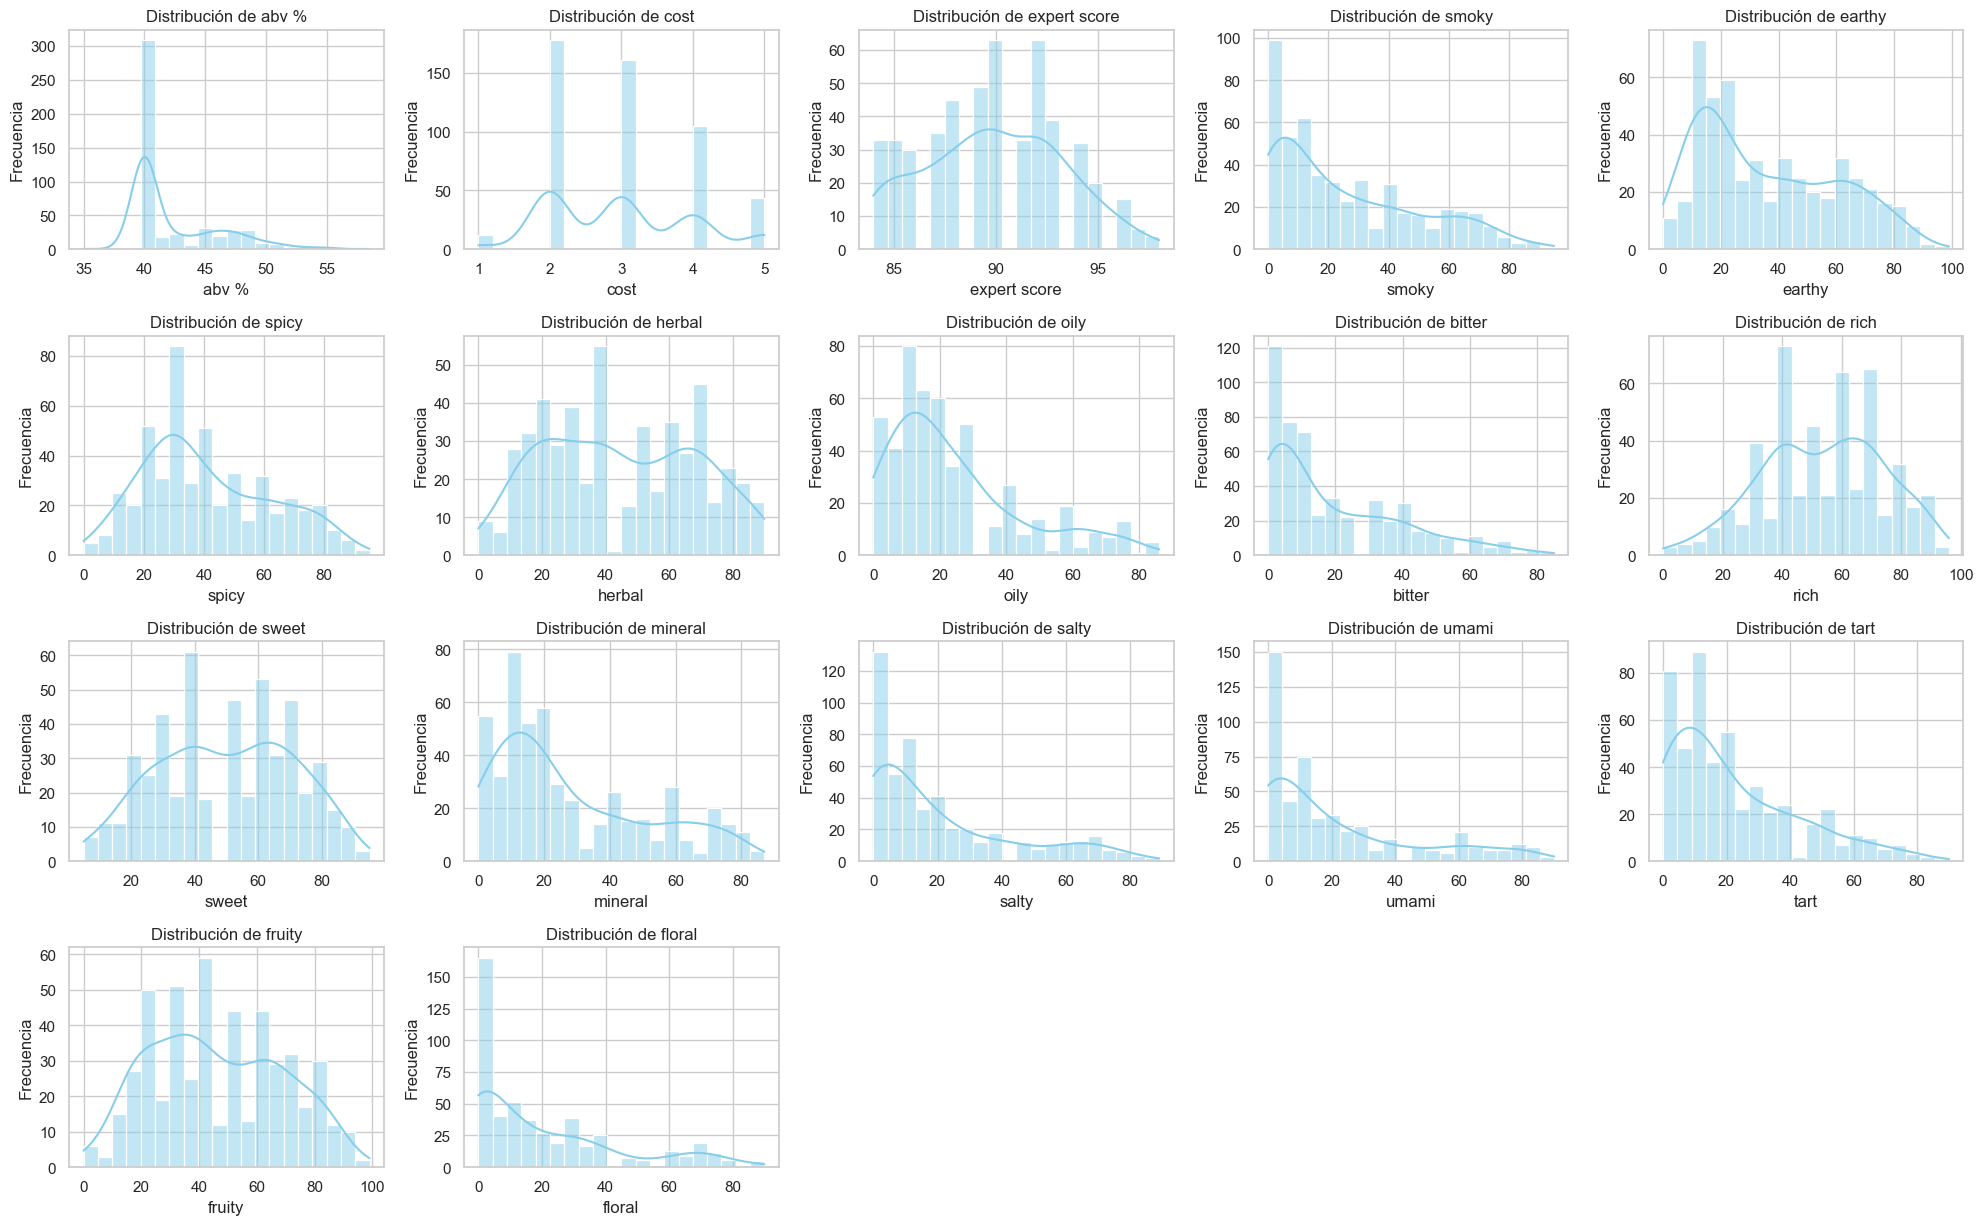

In [7]:
# Configuración de gráficos
sns.set_theme(style="whitegrid")

# Cargar los datos
file_path = "distiler.csv" 
data = pd.read_csv(file_path)

# 1. Exploración inicial
print("Información general del DataFrame:")
data.info()

print("\nPrimeras filas del DataFrame:")
display(data.head())

# Resumen estadístico
print("\nEstadísticas descriptivas:")
display(data.describe())

# Identificar valores faltantes
missing_values = data.isnull().sum()
print("\nValores faltantes por columna:")
print(missing_values[missing_values > 0])

# Visualización de distribuciones
def plot_distributions(dataframe, columns, bins=20):
    plt.figure(figsize=(20, 15))
    for i, column in enumerate(columns, 1):
        plt.subplot(5, 5, i)
        sns.histplot(dataframe[column], kde=True, bins=bins, color='skyblue')
        plt.title(f'Distribución de {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

numeric_columns = data.select_dtypes(include=np.number).columns
print("\nVisualizando distribuciones de variables numéricas:")
plot_distributions(data, numeric_columns)

In [8]:
# 2. Limpieza de datos
# Manejo de valores faltantes
data["cask"].fillna("Unknown", inplace=True)
data["abv %"].fillna(data["abv %"].median(), inplace=True)

print("\nValores faltantes después de limpieza:")
print(data.isnull().sum())

# Identificación de outliers (utilizando el rango intercuartílico)
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers

print("\nOutliers detectados en la columna 'cost':")
outliers_cost = detect_outliers_iqr(data, "cost")
display(outliers_cost)


Valores faltantes después de limpieza:
name                0
type                0
cask                0
location            0
age                 0
abv %               0
cost                0
badge               0
# ratings           0
community rating    0
flavor summary      0
expert              0
expert score        0
smoky               0
earthy              0
spicy               0
herbal              0
oily                0
bitter              0
rich                0
sweet               0
mineral             0
salty               0
umami               0
tart                0
fruity              0
floral              0
dtype: int64

Outliers detectados en la columna 'cost':


,name,type,cask,location,age,abv %,cost,badge,# ratings,community rating,...,oily,bitter,rich,sweet,mineral,salty,umami,tart,fruity,floral


In [9]:
# 3. División en conjuntos de entrenamiento y prueba
train, test = train_test_split(data, test_size=0.2, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento: {len(train)}")
print(f"Tamaño del conjunto de prueba: {len(test)}")

# Guardar los conjuntos para uso posterior
train.to_csv("train_data.csv", index=False)
test.to_csv("test_data.csv", index=False)

print("\nConjuntos de entrenamiento y prueba creados y guardados.")


Tamaño del conjunto de entrenamiento: 400
Tamaño del conjunto de prueba: 100

Conjuntos de entrenamiento y prueba creados y guardados.


### 3. Regresión Lineal [20 puntos]:
---
1. Entrenar un modelo de Regresión Lineal utilizando las variables predictoras seleccionadas para
predecir el rating de las bebidas.
2. Evaluar el rendimiento del modelo utilizando métricas como el Mean Squared Error (MSE) y el
coeficiente de determinación (�!).
3. Interpretar los coeficientes obtenidos y su significado en el contexto del problema.
4. Evaluar los resultados del modelo desde una perspectiva probabilística

In [10]:
# 1. Selección de variables predictoras y la variable objetivo
# Variables predictoras: seleccionar columnas relevantes para predecir el rating
# Suponiendo que las variables relacionadas con sabores y precio son relevantes:
predictors = ["cost", "sweet", "fruity", "smoky", "abv %"]  # Cambiar según relevancia
target = "community rating"  # Variable objetivo

# Filtrar filas sin valores faltantes en las columnas seleccionadas
data_cleaned = data.dropna(subset=predictors + [target])

# Separar en variables predictoras (X) y variable objetivo (y)
X = data_cleaned[predictors]
y = data_cleaned[target]

# Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Reemplazar 'unknown' por NaN
y_train.replace('unknown', np.nan, inplace=True)
# Imputar los valores NaN con la media (o cualquier otra estrategia)
imputer = SimpleImputer(strategy='mean')  # Usa 'mean', 'median' o 'most_frequent'
y_train = imputer.fit_transform(y_train.values.reshape(-1, 1))

# Ahora, puedes entrenar el modelo
#model.fit(X_train, y_train)

# 2. Entrenamiento del modelo de Regresión Lineal
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
# 3. Evaluación del modelo
y_pred = model.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")

ValueError: could not convert string to float: 'unknown'

In [17]:
# 4. Interpretación de los coeficientes
coefficients = pd.DataFrame({
    "Variable": predictors,
    "Coeficiente": model.coef_
})
print("\nCoeficientes del modelo:")
display(coefficients)

ValueError: Per-column arrays must each be 1-dimensional

In [18]:
# 5. Evaluación desde una perspectiva probabilística
# Gráfica de predicciones vs valores reales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle="--")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales")
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

<Figure size 800x600 with 0 Axes>

### 4. Clasificación [15 puntos]:
---
1. Etiquetar los ratings como positivos (por encima de 3.5), neutrales (entre 2.5 y 3.5), y negativos
(por debajo de 2.5), asegurando que las clases estén balanceadas o utilizando técnicas de
resampling.
2. Entrenar los mismos modelos de clasificación utilizados en la sección binaria (Regresión Logística,
kNN, SVM, Naive Bayes, Árboles de Decisión, Random Forests), ajustados para clasificación
multiclase.
3. Utilizar validación cruzada para op@mizar hiperparámetros.
4. Reportar las matrices de confusión para evaluar el rendimiento en cada clase. Evaluar las métricas
de accuracy, precision, recall y F1-Score.
5. Comparar los resultados de los modelos binarios con los modelos mul@clase.

In [19]:
# 1. Etiquetar los rangos
def label_rating(rating):
    if rating > 3.5:
        return "positivo"
    elif 2.5 <= rating <= 3.5:
        return "neutral"
    else:
        return "negativo"

# Crear la columna etiquetada
data_cleaned["rating_category"] = data_cleaned[target].apply(label_rating)

# Comprobar balanceo de clases
print("\nDistribución de clases:")
print(data_cleaned["rating_category"].value_counts())

TypeError: '>' not supported between instances of 'str' and 'float'

In [20]:
# 2. Balancear las clases utilizando SMOTE
X = data_cleaned[predictors]
y = data_cleaned["rating_category"]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Balancear clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDistribución de clases después de balancear (entrenamiento):")
print(pd.Series(y_train_balanced).value_counts())

KeyError: 'rating_category'

In [ ]:
# 3. Modelos a entrenar
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

NameError: name 'LogisticRegression' is not defined

In [ ]:
# 4. Entrenamiento y evaluación
for model_name, model in models.items():
    print(f"\nEntrenando modelo: {model_name}")
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    
    # Reporte de métricas
    print("\nMétricas de clasificación:")
    print(classification_report(y_test, y_pred, target_names=["negativo", "neutral", "positivo"]))
    
    # Matriz de confusión
    print("\nMatriz de confusión:")
    cm = confusion_matrix(y_test, y_pred, labels=["negativo", "neutral", "positivo"])
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negativo", "neutral", "positivo"])
    display.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.show()

NameError: name 'models' is not defined

### 5. Optimización de hiperparámetros [15 puntos]:
---
1. Aplicar técnicas de optimización de hiperparámetros (e.g., Grid Search, Random Search) para
encontrar los valores óptimos de los hiperparámetros de los modelos LASSO y Ridge.
2. Evaluar el rendimiento de los modelos con los hiperparámetros optimizados y comparar con los
resultados anteriores.

#### GridSearch

In [21]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
ridge = Ridge()

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

grid_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

print("Mejor alpha para LASSO:", grid_lasso.best_params_)
print("Mejor alpha para Ridge:", grid_ridge.best_params_)


Mejor alpha para LASSO: {'alpha': 0.01}
Mejor alpha para Ridge: {'alpha': 1}


#### Random Search

In [22]:
from sklearn.model_selection import RandomizedSearchCV

random_lasso = RandomizedSearchCV(estimator=lasso, param_distributions={'alpha': [0.01, 0.1, 1, 10, 100]}, 
                                   n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
random_lasso.fit(X_train, y_train)

random_ridge = RandomizedSearchCV(estimator=ridge, param_distributions={'alpha': [0.01, 0.1, 1, 10, 100]}, 
                                   n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
random_ridge.fit(X_train, y_train)

print("Mejor alpha para LASSO:", random_lasso.best_params_)
print("Mejor alpha para Ridge:", random_ridge.best_params_)

Mejor alpha para LASSO: {'alpha': 0.01}
Mejor alpha para Ridge: {'alpha': 1}


c:\Users\benji\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\benji\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


#### Evaluacion del rendimiento

In [23]:
from sklearn.metrics import mean_squared_error

lasso_best = grid_lasso.best_estimator_
y_pred_lasso = lasso_best.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

ridge_best = grid_ridge.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("MSE LASSO optimizado:", mse_lasso)
print("MSE Ridge optimizado:", mse_ridge)

ValueError: could not convert string to float: 'unknown'

### 6. Conclusiones [10 puntos]:
---
1. Presentar conclusiones relevantes sobre los resultados y el trabajo realizado.
2. Discutir las ventajas y desventajas de cada modelo utilizado, y su aplicabilidad en el contexto de
predicción de ratings de bebidas alcohólicas.
3. Proponer posibles mejoras o extensiones al análisis realizado

### 7. Crédito Extra: Regresión kNN [10 puntos]
---
1. Entrenar un modelo de regresión kNN, incluyendo el proceso de optimización del hiperparámetro
k utilizando 5-fold cross validation.
2. Comparar los resultados del modelo kNN con los resultados anteriores.

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\benji\anaconda3\Lib\site-packages\pip\_vend

  Obtaining dependency information for scikit-learn==1.2.2 from https://files.pythonhosted.org/packages/db/98/169b46a84b48f92df2b5e163fce75d471f4df933f8b3d925a61133210776/scikit_learn-1.2.2-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.3 MB 1.2 MB/s eta 0:00:08
    --------------------------------------- 0.2/8.3 MB 1.5 MB/s eta 0:00:06
   - -------------------------------------- 0.3/8.3 MB 1.8 MB/s eta 0:00:05
   - -------------------------------------- 0.4/8.3 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.3 MB 2.0 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.3 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.3 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.3 MB 1.4 MB/s eta 0:00:06
   -- -----------------------

### 8. Crédito Extra: Regresión No Lineal [10 puntos]
---
1. Evaluar modelos de Regresión No Lineal (polinómica u otras variantes), incluyendo el proceso de
optimización de hiperparámetros utilizando 5-fold cross validation.
2. Comparar los resultados del no lineal con los resultados anteriores.

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [2, 3, 4, 5],  # Grados del polinomio
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]  # Regularización de Ridge
}

grid_poly = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_poly.fit(X_train, y_train)

print("Mejores parámetros (Regresión Polinómica):", grid_poly.best_params_)
print("Mejor puntuación (neg_mean_squared_error):", grid_poly.best_score_)

NameError: name 'X_train' is not defined